# Model train

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

df = pd.read_csv("data/processed/employee_perf_clean.csv")
df.head()


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,ExperienceGap
0,E1001000,32,1,2,2,5,13,2,10,3,...,10,2,2,10,7,0,8,0,3,0
1,E1001006,47,1,2,2,5,13,2,14,4,...,20,2,3,7,7,1,7,0,3,13
2,E1001007,40,1,1,1,5,13,1,5,4,...,20,2,3,18,13,1,12,0,4,2
3,E1001009,41,1,0,0,3,8,2,10,4,...,23,2,2,21,6,12,6,0,3,2
4,E1001010,60,1,2,2,5,13,2,16,4,...,10,1,3,2,2,2,2,0,3,8


## Feature Selection

In [3]:
# Dropping the first columns as it is of no use for analysis.
df.drop(['EmpNumber'],inplace=True,axis=1)

In [4]:
# Finding out the correlation coeffecient to find out which predictors are significant.
df.corr()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,ExperienceGap
Age,1.000000,-0.040107,-0.055905,-0.098368,-0.000104,-0.037665,0.040579,0.020937,0.207313,0.013814,...,0.680886,-0.016053,-0.019563,0.318852,0.217163,0.228199,0.205098,-0.189317,-0.040164,0.538103
Gender,-0.040107,1.000000,0.009922,-0.042169,-0.010925,0.011332,-0.043608,-0.001507,-0.022960,0.000033,...,-0.061055,-0.057654,0.015793,-0.030392,-0.031823,-0.021575,-0.036643,0.035758,-0.001780,-0.046432
EducationBackground,-0.055905,0.009922,1.000000,-0.001097,-0.026874,-0.012325,0.012382,-0.013919,-0.047978,0.045028,...,-0.027929,0.051596,0.022890,-0.009887,-0.003215,0.014277,0.002767,0.027161,0.005607,-0.025299
MaritalStatus,-0.098368,-0.042169,-0.001097,1.000000,0.067272,0.038023,0.028520,-0.019148,0.026737,-0.032467,...,-0.093537,0.026045,0.014154,-0.075728,-0.076663,-0.052951,-0.061908,0.162969,0.024172,-0.041654
EmpDepartment,-0.000104,-0.010925,-0.026874,0.067272,1.000000,0.568973,-0.045233,0.007707,0.019175,-0.019237,...,0.016065,0.016438,0.068875,0.047677,0.069602,0.052315,0.033850,0.048006,-0.162615,-0.027890
EmpJobRole,-0.037665,0.011332,-0.012325,0.038023,0.568973,1.000000,-0.086251,0.022939,-0.016792,0.044612,...,-0.049529,0.004452,-0.007519,-0.009047,0.019383,0.012190,-0.004504,0.037508,-0.096209,-0.053442
BusinessTravelFrequency,0.040579,-0.043608,0.012382,0.028520,-0.045233,-0.086251,1.000000,-0.020935,0.002064,0.012267,...,0.042736,0.006720,-0.040969,-0.015029,-0.006541,-0.020824,-0.028073,0.007217,-0.031025,0.069193
DistanceFromHome,0.020937,-0.001507,-0.013919,-0.019148,0.007707,0.022939,-0.020935,1.000000,0.045856,-0.017719,...,0.027306,-0.032082,-0.044788,0.021908,0.019898,0.013246,0.017860,0.063248,-0.046142,0.012361
EmpEducationLevel,0.207313,-0.022960,-0.047978,0.026737,0.019175,-0.016792,0.002064,0.045856,1.000000,-0.037103,...,0.151062,-0.013674,0.010276,0.076332,0.066672,0.054313,0.088988,-0.049118,0.020529,0.113733
EmpEnvironmentSatisfaction,0.013814,0.000033,0.045028,-0.032467,-0.019237,0.044612,0.012267,-0.017719,-0.037103,1.000000,...,-0.012894,0.001192,-0.000262,-0.000561,0.025491,0.010732,-0.011702,-0.123490,0.395561,-0.015727


###  Correlation Analysis Insights for feature selection

There are a large number of columns in the predictor variables. Therefore, the correlation coefficient was calculated to identify which predictors are important for the model. Only the features with a correlation coefficient greater than **0.1** with the *Performance Rating* were selected. These selected features were then used for training the machine learning models.

Based on the correlation analysis, the most important features affecting employee performance are:

- **Department**  
- **Job Role**  
- **Environment Satisfaction**  
- **Last Salary Hike Percent**  
- **Work Life Balance**  
- **Experience Years at This Company**  
- **Experience Years in Current Role**  
- **Years Since Last Promotion**  
- **Years With Current Manager**

Standardization and Label Encoding were also applied as part of the feature transformation process.

A separate analysis using *all predictors* was carried out, but it resulted in decreased accuracy. Similarly, applying **Principal Component Analysis (PCA)** also reduced the model accuracy, indicating that dimensionality reduction was not beneficial for this dataset.

###  Top 3 Factors Affecting Employee Performance

1. **Employee Environment Satisfaction**  
2. **Employee Last Salary Hike Percent**  
3. **Years Since Last Promotion**


In [5]:
# Selected only the important columns
y = df.PerformanceRating
X = df.iloc[:,[4,5,9,16,20,21,22,23,24]] # Taking only variables with correlation coeffecient greater than 0.1
X.head()

,EmpDepartment,EmpJobRole,EmpEnvironmentSatisfaction,EmpLastSalaryHikePercent,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,5,13,4,12,2,10,7,0,8
1,5,13,4,12,3,7,7,1,7
2,5,13,4,21,3,18,13,1,12
3,3,8,2,15,2,21,6,12,6
4,5,13,1,14,3,2,2,2,2


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10) 
X_train.shape, X_test.shape,y_train.shape, y_test.shape


((960, 9), (240, 9), (960,), (240,))

In [7]:
# Standardization technique is used
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [8]:
X_train.shape, X_test.shape

((960, 9), (240, 9))

1. Logistic Regression

In [9]:
# Training the model
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

LogisticRegression()

In [10]:
# Predicting the model
y_predict_lr = model_lr.predict(X_test)

In [11]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_lr))
print(classification_report(y_test,y_predict_lr))

0.8541666666666666
              precision    recall  f1-score   support

           2       0.62      0.61      0.61        38
           3       0.90      0.92      0.91       179
           4       0.89      0.74      0.81        23

    accuracy                           0.85       240
   macro avg       0.80      0.76      0.78       240
weighted avg       0.85      0.85      0.85       240



In [12]:
confusion_matrix(y_test,y_predict_lr)

array([[ 23,  15,   0],
       [ 12, 165,   2],
       [  2,   4,  17]])

In [13]:
lr= accuracy_score(y_test,y_predict_lr)

2. Support Vector Machine

In [14]:
# Training the model
from sklearn.svm import SVC
rbf_svc = SVC(kernel='rbf', C=100, random_state=10).fit(X_train,y_train)

In [15]:
# Predicting the model
y_predict_svm = rbf_svc.predict(X_test)

In [16]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_svm))
print(classification_report(y_test,y_predict_svm))

0.8666666666666667
              precision    recall  f1-score   support

           2       0.77      0.79      0.78        38
           3       0.92      0.91      0.91       179
           4       0.64      0.70      0.67        23

    accuracy                           0.87       240
   macro avg       0.78      0.80      0.79       240
weighted avg       0.87      0.87      0.87       240



In [17]:
confusion_matrix(y_test,y_predict_svm)


array([[ 30,   8,   0],
       [  8, 162,   9],
       [  1,   6,  16]])

In [18]:
svm= accuracy_score(y_test,y_predict_svm)

3. Decision Tree with Grid Searchcv

In [19]:
# Training the model
from sklearn.tree import DecisionTreeClassifier

classifier_dt=DecisionTreeClassifier(random_state=42,splitter='best')
parameters=[{'min_samples_split':[2,3,4,5],'criterion':['gini']},{'min_samples_split':[2,3,4,5],'criterion':['entropy']}]

model_dt_grid=GridSearchCV(estimator=classifier_dt, param_grid=parameters, scoring='accuracy',cv=10)
model_dt_grid.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid=[{'criterion': ['gini'],
                          'min_samples_split': [2, 3, 4, 5]},
                         {'criterion': ['entropy'],
                          'min_samples_split': [2, 3, 4, 5]}],
             scoring='accuracy')

In [20]:
model_dt_grid.best_params_

{'criterion': 'entropy', 'min_samples_split': 5}

In [21]:
# Predicting the model
y_predict_dt = model_dt_grid.predict(X_test)

In [22]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_dt))
print(classification_report(y_test,y_predict_dt))

0.925
              precision    recall  f1-score   support

           2       0.87      0.89      0.88        38
           3       0.96      0.96      0.96       179
           4       0.77      0.74      0.76        23

    accuracy                           0.93       240
   macro avg       0.87      0.86      0.86       240
weighted avg       0.92      0.93      0.92       240



In [23]:
confusion_matrix(y_test,y_predict_dt)

array([[ 34,   3,   1],
       [  4, 171,   4],
       [  1,   5,  17]])

In [24]:
dt_grid= accuracy_score(y_test,y_predict_dt)

4. Random Forest with Gridsearchcv

In [25]:
# Training the model
from sklearn.ensemble import RandomForestClassifier

classifier_rfg=RandomForestClassifier(random_state=33,n_estimators=23)
parameters=[{'min_samples_split':[2,3,4,5],'criterion':['gini','entropy'],'min_samples_leaf':[1,2,3]}]

model_rf_grid=GridSearchCV(estimator=classifier_rfg, param_grid=parameters, scoring='accuracy',cv=10)
model_rf_grid.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=RandomForestClassifier(n_estimators=23, random_state=33),
             param_grid=[{'criterion': ['gini', 'entropy'],
                          'min_samples_leaf': [1, 2, 3],
                          'min_samples_split': [2, 3, 4, 5]}],
             scoring='accuracy')

In [26]:
best_rf = model_rf_grid.best_estimator_


In [27]:
best_rf

RandomForestClassifier(min_samples_split=3, n_estimators=23, random_state=33)

In [28]:
model_rf_grid.best_params_

{'criterion': 'gini', 'min_samples_leaf': 1, 'min_samples_split': 3}

In [29]:
# Predicting the model
y_predict_rf = model_rf_grid.predict(X_test)

In [30]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_rf))
print(classification_report(y_test,y_predict_rf))

0.9416666666666667
              precision    recall  f1-score   support

           2       0.90      0.92      0.91        38
           3       0.96      0.97      0.96       179
           4       0.86      0.78      0.82        23

    accuracy                           0.94       240
   macro avg       0.91      0.89      0.90       240
weighted avg       0.94      0.94      0.94       240



In [31]:
confusion_matrix(y_test,y_predict_rf)

array([[ 35,   3,   0],
       [  3, 173,   3],
       [  1,   4,  18]])

In [32]:
rf_grid= accuracy_score(y_test,y_predict_rf)

5. Naive Bayes

In [33]:
# Training the model
from sklearn.naive_bayes import BernoulliNB
model_nb = BernoulliNB()
model_nb.fit(X_train,y_train)

BernoulliNB()

In [34]:
# Predicting the model
y_predict_nb = model_nb.predict(X_test)

In [35]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_nb))
print(classification_report(y_test,y_predict_nb))

0.8
              precision    recall  f1-score   support

           2       0.68      0.55      0.61        38
           3       0.82      0.96      0.88       179
           4       0.00      0.00      0.00        23

    accuracy                           0.80       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.72      0.80      0.75       240



C:\Users\sanjay\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sanjay\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sanjay\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
confusion_matrix(y_test,y_predict_nb)

array([[ 21,  17,   0],
       [  8, 171,   0],
       [  2,  21,   0]])

In [37]:
nb= accuracy_score(y_test,y_predict_nb)

6. KNeighbours

In [38]:
# Training the model
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=10,metric='euclidean') # Maximum accuracy for n=10
model_knn.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [39]:
# Predicting the model
y_predict_knn = model_knn.predict(X_test)

In [40]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_knn))
print(classification_report(y_test,y_predict_knn))

0.8416666666666667
              precision    recall  f1-score   support

           2       0.65      0.63      0.64        38
           3       0.88      0.93      0.90       179
           4       0.86      0.52      0.65        23

    accuracy                           0.84       240
   macro avg       0.79      0.69      0.73       240
weighted avg       0.84      0.84      0.84       240



In [41]:
confusion_matrix(y_test,y_predict_knn)

array([[ 24,  13,   1],
       [ 12, 166,   1],
       [  1,  10,  12]])

In [42]:
knn= accuracy_score(y_test,y_predict_knn)

7. Neural Network - ANN

In [43]:
# Training the model
from sklearn.neural_network import MLPClassifier
model_mlp = MLPClassifier(hidden_layer_sizes=(100,100,100),batch_size=10,learning_rate_init=0.01,max_iter=2000,random_state=10)
model_mlp.fit(X_train,y_train)

MLPClassifier(batch_size=10, hidden_layer_sizes=(100, 100, 100),
              learning_rate_init=0.01, max_iter=2000, random_state=10)

In [44]:
# Predicting the model
y_predict_mlp = model_mlp.predict(X_test)

In [45]:
# Finding accuracy, precision, recall and confusion matrix
print(accuracy_score(y_test,y_predict_mlp))
print(classification_report(y_test,y_predict_mlp))

0.85
              precision    recall  f1-score   support

           2       0.89      0.42      0.57        38
           3       0.86      0.96      0.91       179
           4       0.73      0.70      0.71        23

    accuracy                           0.85       240
   macro avg       0.83      0.69      0.73       240
weighted avg       0.85      0.85      0.84       240



In [46]:
confusion_matrix(y_test,y_predict_mlp)

array([[ 16,  22,   0],
       [  1, 172,   6],
       [  1,   6,  16]])

In [47]:
ANN= accuracy_score(y_test,y_predict_mlp)

### Comparision of models

In [48]:
Accuracy_Score = [lr,svm,dt_grid,rf_grid,nb,knn,ANN]
Models = ['Logistic Regression', 'Support Vector Machine' , 'Decision Tree with GridSearchCV', 'Random Forest with GridSearchCV',
          'Naive Bayes Bernoulli', 'K-Nearest Neighbor', 'Artificial Neural Network']

<Axes: >

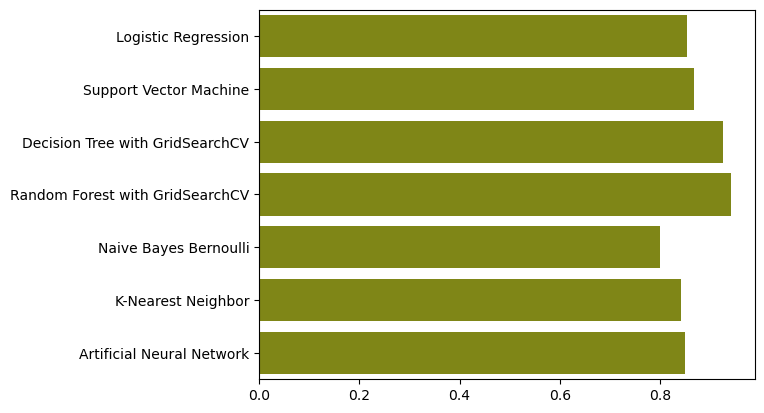

In [49]:
sns.barplot(x=Accuracy_Score, y=Models, color="xkcd:baby poop green")


###  Insights from Model Performance Comparison

The bar chart compares the accuracy of different machine learning models applied to predict employee Performance Rating. The following insights can be observed:

1. **Random Forest with GridSearchCV achieved the highest accuracy among all models**, indicating that hyperparameter tuning significantly improved the model’s ability to generalize.  
   - The ensemble nature of Random Forest enables it to handle complex relationships and reduce overfitting.

2. **Decision Tree with GridSearchCV also performed very strongly**, showing a major improvement over default Decision Tree models.  
   - However, it is still slightly behind Random Forest because single trees are more prone to variance.

3. **Support Vector Machine and Artificial Neural Network delivered competitive accuracy**, demonstrating their ability to capture non-linear patterns in the data.  
   - SVM performed well due to its margin maximization.
   - ANN delivered robust performance thanks to its multiple layers learning deeper patterns.

4. **K-Nearest Neighbor shows decent performance**, but slightly lower compared to optimized tree-based models.  
   - KNN can struggle with high-dimensional or unevenly scaled data, making its performance moderate.

5. **Logistic Regression performs worse than the advanced models**, due to its linear assumptions and inability to model complex, non-linear relationships in employee performance data.  
   - Still useful as a baseline.

6. **Naive Bayes Bernoulli yields the lowest accuracy**, which is expected because:
   - It assumes strong independence between features.
   - The dataset includes many correlated numeric variables, breaking NB assumptions.

###  Overall Conclusion
- **Random Forest with GridSearchCV is the best-performing model** and is recommended as the final model for deployment.  
- Other strong candidates include **Decision Tree (tuned)** and **ANN**, but RF provides the best balance of accuracy, robustness, and interpretability.


In [50]:
import joblib, os
os.makedirs("models", exist_ok=True)

# Save best estimator
joblib.dump(best_rf, "models/final_random_forest_model.joblib")

# Optionally save the entire GridSearchCV object (useful to inspect cv results later)
joblib.dump(model_rf_grid, "models/gridsearch_random_forest.joblib")

print("Saved best estimator and GridSearchCV to models/ folder.")

Saved best estimator and GridSearchCV to models/ folder.
